# PowerPredict - kratak pregled

Ovaj notebook daje sažet pregled projekta PowerPredict: od pripreme podataka i feature engineeringa, preko baseline pristupa, do poređenja najboljih modela. Ideja je da se na jednom mestu vidi tok rada i najvažniji rezultati.

Poseban fokus je na tome kako se problem vremenskih serija prevodi u nadgledano učenje: model ne dobija buduće informacije, već uči iz kalendarskih osobina, prethodnih vrednosti potrošnje i agregiranih statistika.


In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
LOGS_DIR = DATA_DIR / "logs"
GRAPHS_DIR = DATA_DIR / "graphs"
SPLIT_DIR = DATA_DIR / "processed" / "split"

BEST_MODEL_PATHS = {
    "GRU": LOGS_DIR / "gru_logs" / "best_gru_model_summary.csv",
    "LSTM": LOGS_DIR / "lstm_logs" / "best_lstm_model_summary.csv",
    "Random Forest": LOGS_DIR / "random_forest_logs" / "best_random_forest_model_summary.csv",
    "Gradient Boosting": LOGS_DIR / "gradient_boosting_logs" / "best_gradient_boosting_model_summary.csv",
}


def show_image(path, title=None):
    from IPython.display import Image, Markdown, display

    if path.exists():
        if title:
            display(Markdown(f"### {title}"))
        display(Image(filename=str(path)))


def show_table(df):
    from IPython.display import display

    display(df)


def read_first_row(path):
    import pandas as pd

    return pd.read_csv(path).iloc[0] if path.exists() else None

## 1. Podaci

Predviđa se satna potrošnja električne energije. Pošto su podaci vremenski uređeni, podela na trening, validation i test skup nije nasumična, već hronološka: model uči iz prošlosti, podešava se na kasnijem periodu, a zatim se proverava na novijim podacima.

Takva podela imitira stvarnu upotrebu modela. U praksi bismo uvek imali istorijske podatke i pokušavali da procenimo potrošnju za naredne sate ili dane, pa je važno da evaluacija ne dozvoli curenje informacija iz budućnosti.


In [6]:
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 160)

for title, path in [
    ("Dataset report", LOGS_DIR / "dataset_report.csv"),
    ("Train / validation / test split", LOGS_DIR / "split_report.csv"),
]:
    if path.exists():
        display(Markdown(f"### {title}"))
        show_table(pd.read_csv(path))


### Dataset report

,Opis,Vrednost
0,Minimalna satna potrosnja Global_active_power,0.124
1,Maksimalna satna potrosnja Global_active_power,6.5605
2,Prosecna satna potrosnja Global_active_power,1.0913
3,Medijana satne potrosnje Global_active_power,0.8023
4,Procenat sati sa potrosnjom ispod ili jednako 0.5 kWh,39.33
5,Procenat sati sa potrosnjom ispod ili jednako 1.0 kWh,55.85
6,Zakljucak,"Veliki deo sati ima nisku potrosnju, pa procentualne metrike treba tumaciti pazljivo."


### Train / validation / test split

,Opis,Vrednost
0,Broj redova u train skupu,23671
1,Broj redova u validation skupu,5072
2,Broj redova u test skupu,5073
3,Train period,2006-12-24 00:00:00 - 2009-09-14 06:00:00
4,Validation period,2009-09-14 07:00:00 - 2010-04-18 14:00:00
5,Test period,2010-04-18 15:00:00 - 2010-11-25 23:00:00


## 2. Feature engineering

Tabela ispod je kratak primer kako izgleda trening skup posle feature engineeringa (prvih nekoliko redova iz `train.csv`).

Ciljna vrednost je `Energy_kWh`, a ostale kolone joj daju kontekst: sat u danu, dan u nedelji, mesec, vikend/noć/praznik indikatore, prethodne vrednosti potrošnje (`lag_1h`, `lag_24h`, `lag_168h`) i rolling statistike. Lag i rolling kolone su posebno važne jer modelu daju memoriju o prethodnoj potrošnji bez direktnog gledanja u budućnost.

Kalendarske kolone hvataju ponavljajuće obrasce, na primer razliku između radnih dana i vikenda ili dnevni ritam potrošnje. Sa druge strane, lag i rolling kolone pomažu modelu da prepozna kratkoročni trend, sezonalnost i nagle promene koje se ne vide samo iz datuma i vremena.


In [7]:
import pandas as pd

train_path = SPLIT_DIR / "train.csv"
if train_path.exists():
    sample_columns = [
        "datetime",
        "Global_active_power",
        "Global_reactive_power",
        "Global_intensity",
        "Energy_kWh",
        "hour",
        "day_of_week",
        "month",
        "is_weekend",
        "is_night",
        "is_holiday",
        "lag_1h",
        "lag_24h",
        "lag_168h",
        "rolling_mean_24h",
        "rolling_std_7d",
    ]
    available_columns = pd.read_csv(train_path, nrows=0).columns
    sample_columns = [column for column in sample_columns if column in available_columns]
    train_sample = pd.read_csv(train_path, parse_dates=["datetime"], usecols=sample_columns).head(5)
    show_table(train_sample)


,datetime,Global_active_power,Global_reactive_power,Global_intensity,Energy_kWh,hour,day_of_week,month,is_weekend,is_night,lag_1h,lag_24h,lag_168h,rolling_mean_24h,rolling_std_7d,is_holiday
0,2006-12-24 00:00:00,4.0280,0.0907,17.0800,4.0280,0,6,12,1,1,5.5625,1.6982,1.8825,3.3148,1.2361,0
1,2006-12-24 01:00:00,3.2757,0.0518,14.0167,3.2757,1,6,12,1,1,4.0280,1.7228,3.3494,3.4119,1.2479,0
2,2006-12-24 02:00:00,2.3030,0.1037,10.0667,2.3030,2,6,12,1,1,3.2757,1.7008,1.5873,3.4766,1.2473,0
3,2006-12-24 03:00:00,1.6068,0.0719,7.3467,1.6068,3,6,12,1,1,2.3030,1.7715,1.6622,3.5017,1.2477,0
4,2006-12-24 04:00:00,1.5761,0.0679,7.2667,1.5761,4,6,12,1,1,1.6068,1.8916,2.2158,3.4949,1.2478,0


## 3. Baseline

Baseline koristi `lag_24h`: vrednost iz istog sata prethodnog dana. To je jednostavna, ali vrlo smislena pretpostavka, jer potrošnja električne energije često ima jak dnevni obrazac.

Zbog toga baseline služi kao realan minimum koji složeniji modeli treba da pobede. Ako model sa više osobina i složenijom strukturom ne daje bolji rezultat od ove jednostavne heuristike, onda dodatna kompleksnost nije opravdana.


,Dataset,MAE,RMSE,WAPE,Broj_redova
0,validation,0.6624,0.9550,53.0450,5072
1,test,0.5123,0.7611,53.4677,5073


### Baseline - test MAE po satu

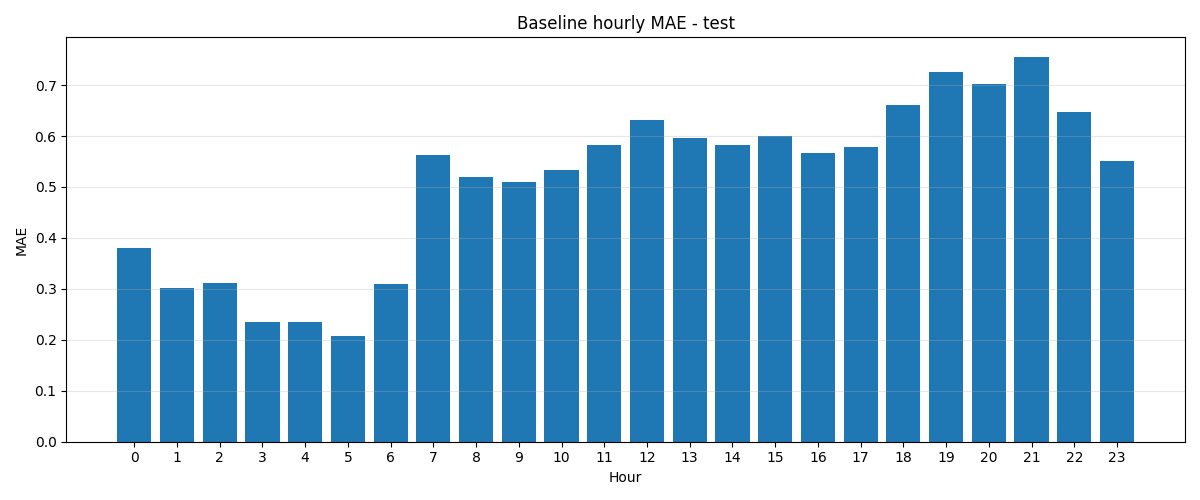

### Baseline - distribucija greske

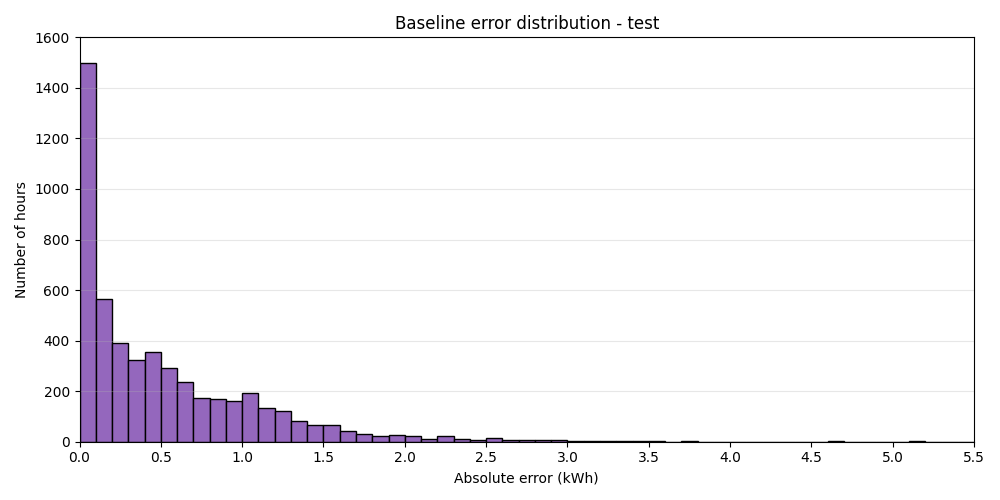

### Baseline - actual vs predicted

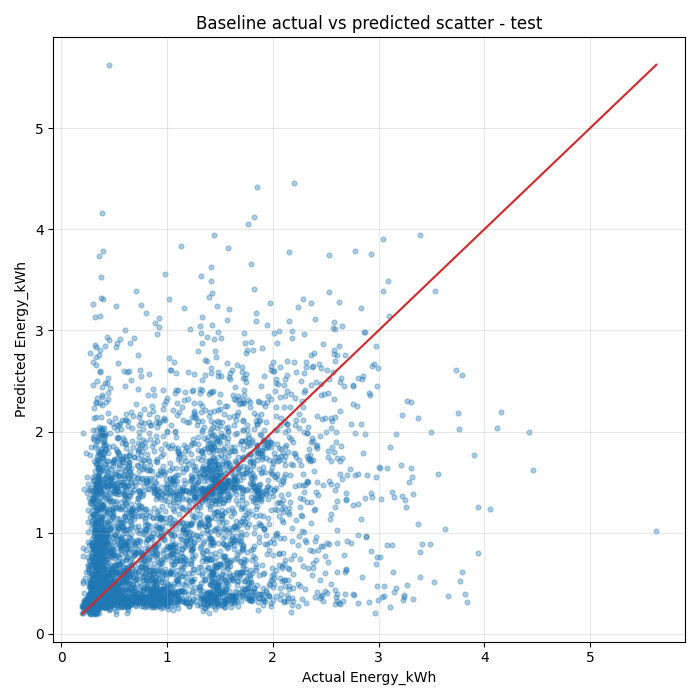

In [8]:
import pandas as pd

baseline_report_path = LOGS_DIR / "baseline_report.csv"
if baseline_report_path.exists():
    baseline_report = pd.read_csv(baseline_report_path)
    baseline_summary = baseline_report[baseline_report["Report_Type"] == "summary"]
    show_table(baseline_summary[["Dataset", "MAE", "RMSE", "WAPE", "Broj_redova"]])

baseline_graphs_dir = GRAPHS_DIR / "baseline_graphs"
show_image(baseline_graphs_dir / "baseline_test_hourly_mae.png", "Baseline - test MAE po satu")
show_image(baseline_graphs_dir / "baseline_test_error_distribution.png", "Baseline - distribucija greske")
show_image(baseline_graphs_dir / "baseline_test_actual_vs_predicted_scatter.png", "Baseline - actual vs predicted")


## 4. Najbolji modeli

Modeli su birani po validation MAE, jer je validation skup korišćen za poređenje konfiguracija pre konačne provere na test skupu. Ovde je prikazan kompaktan pregled rezultata.

MAE je pogodan za ovaj zadatak zato što direktno govori kolika je prosečna apsolutna greška u jedinicama potrošnje. Manja vrednost znači da su predikcije u proseku bliže stvarnim satnim vrednostima.


In [9]:
import pandas as pd

rows = []
if baseline_report_path.exists():
    baseline_test = baseline_summary[baseline_summary["Dataset"] == "test"]
    if not baseline_test.empty:
        row = baseline_test.iloc[0]
        rows.append({
            "Model family": "Baseline",
            "Model": "lag_24h",
            "validation_MAE": None,
            "test_MAE": row["MAE"],
            "test_RMSE": row["RMSE"],
            "test_WAPE": row["WAPE"],
        })

for family, path in BEST_MODEL_PATHS.items():
    row = read_first_row(path)
    if row is not None:
        rows.append({
            "Model family": family,
            "Model": row["Model"],
            "validation_MAE": row.get("validation_MAE"),
            "test_MAE": row["test_MAE"],
            "test_RMSE": row["test_RMSE"],
            "test_WAPE": row["test_WAPE"],
        })

best_summary = pd.DataFrame(rows).sort_values("test_MAE")
show_table(best_summary)


,Model family,Model,validation_MAE,test_MAE,test_RMSE,test_WAPE
2,LSTM,lstm_seq48_h64_l2_d0p2_lr0p0005_bs64,0.3704,0.3267,0.4826,33.9633
4,Gradient Boosting,gradient_boosting_n200_lr0p05_depth5,0.3715,0.3269,0.4693,34.1121
1,GRU,gru_seq24_h64_l1_d0p0_lr0p0005_bs64,0.3714,0.3291,0.4791,34.3047
3,Random Forest,random_forest_n100_depth10_leaf1,0.3737,0.3299,0.4744,34.4243
0,Baseline,lag_24h,NaN,0.5123,0.7611,53.4677


## 5. Trening rekurentnih mreža kroz epohe

Grafici pokazuju kako se loss menja tokom treniranja. Ovo je dobar način da se vidi da li trening (greška) stabilno konvergira ka jednoj vrednosti i da li postoji znak overfitting-a.

Ako trening greška opada, a validation greška počne da raste, model verovatno previše pamti trening skup. Kada se obe krive smiruju na sličnom nivou, to je dobar znak da model uči obrasce koji se prenose i na neviđene podatke.


### GRU - trening

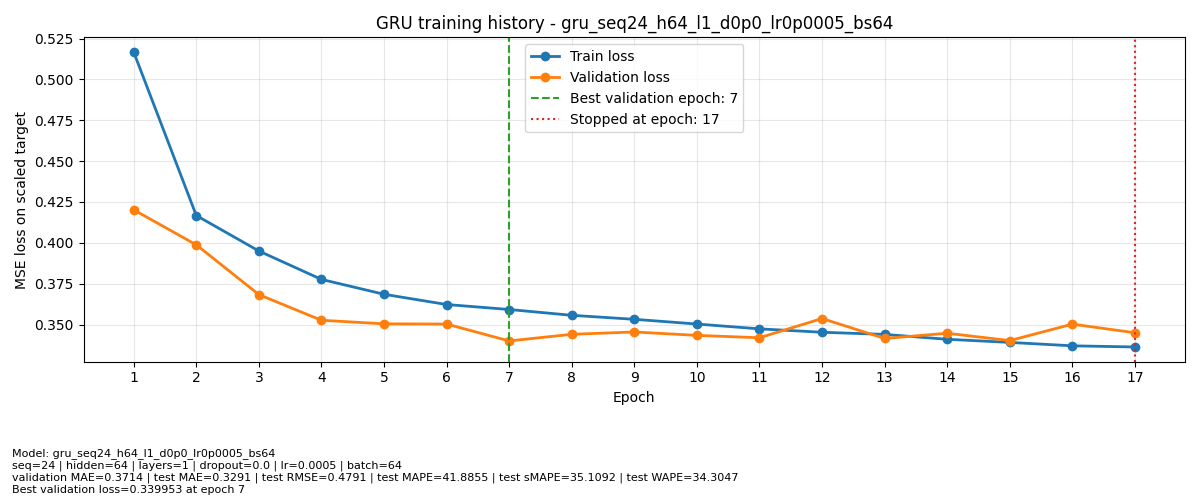

### LSTM - trening

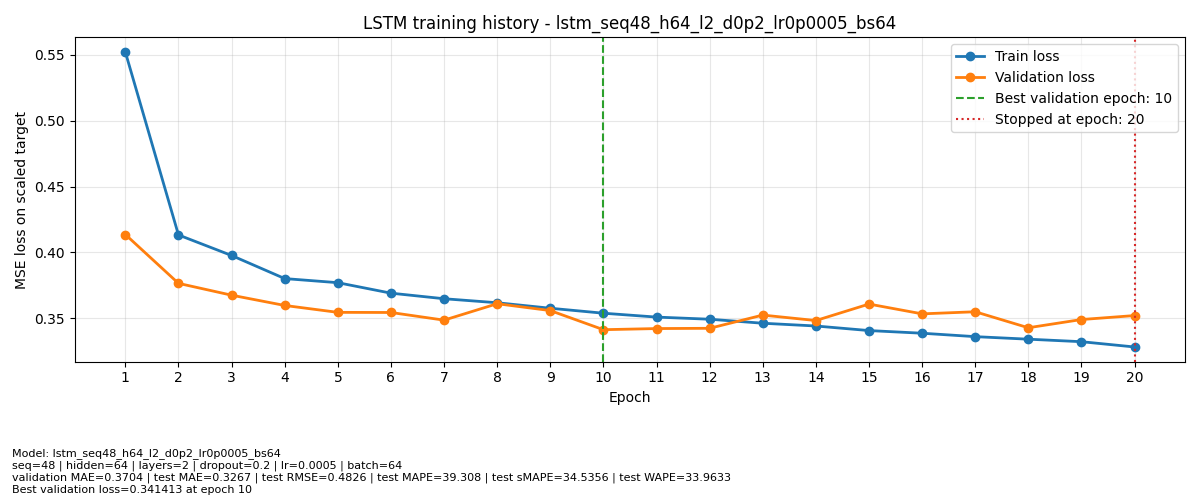

In [10]:
gru_row = read_first_row(BEST_MODEL_PATHS["GRU"])
lstm_row = read_first_row(BEST_MODEL_PATHS["LSTM"])

gru_name = gru_row["Model"] if gru_row is not None else None
lstm_name = lstm_row["Model"] if lstm_row is not None else None

if gru_name:
    show_image(GRAPHS_DIR / "gru_graphs" / f"{gru_name}_training_history.png", "GRU - trening")
if lstm_name:
    show_image(GRAPHS_DIR / "lstm_graphs" / f"{lstm_name}_training_history.png", "LSTM - trening")


## 6. Baseline poređenja

Grafici direktno porede baseline sa najboljim modelom iz svake porodice na test skupu. Za svaki model prikazani su MAE po satu, distribucija greške i scatter `actual vs predicted`, gde se vidi ne samo prosečna greška nego i da li model sistematski promašuje određene opsege potrošnje.

Ovakav prikaz je koristan jer jedna metrika ne govori celu priču. Model može imati dobar ukupni MAE, ali i dalje praviti veće greške u špicevima potrošnje, tokom noći ili u satima kada se obrazac ponašanja menja.


### Baseline vs GRU - MAE po satu

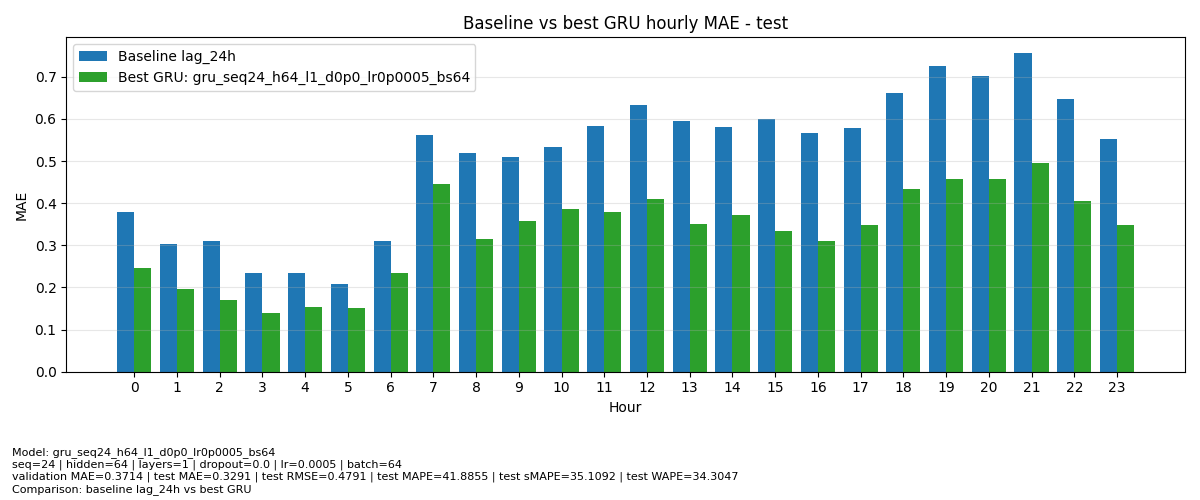

### Baseline vs GRU - distribucija greske

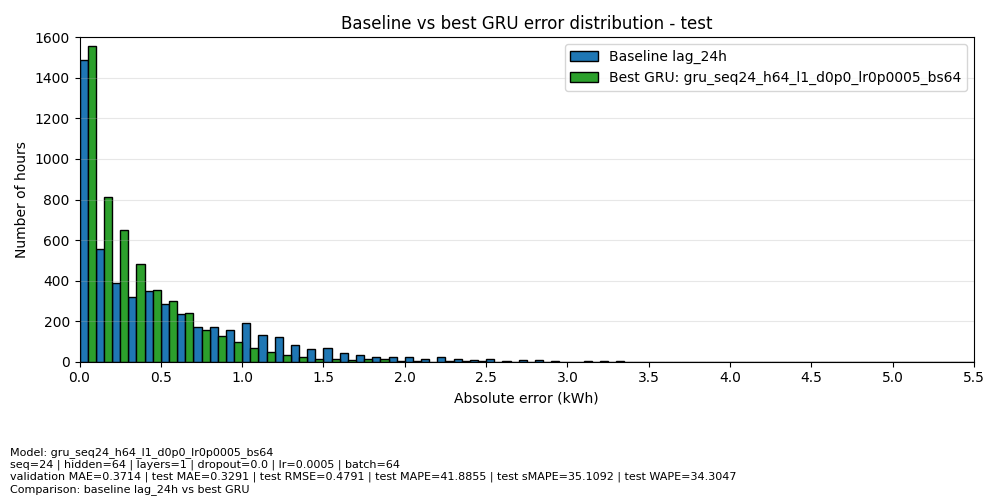

### Baseline vs GRU - actual vs predicted

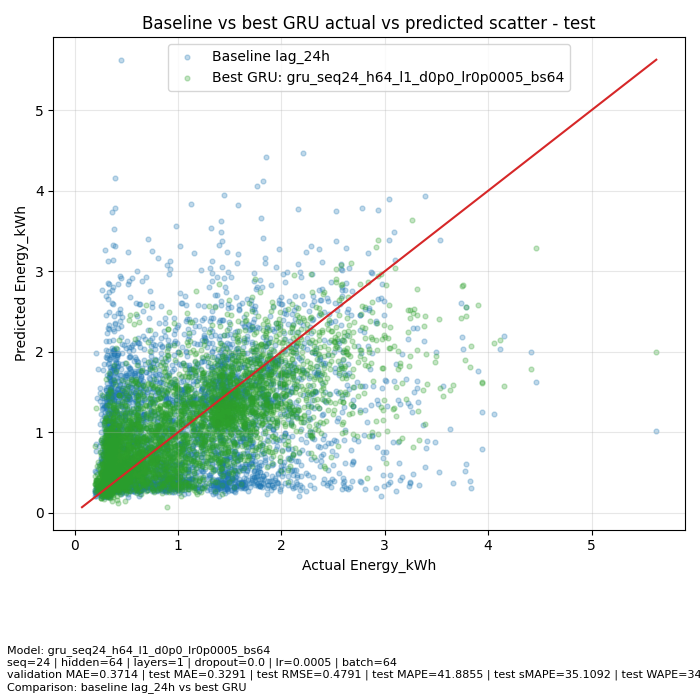

### Baseline vs LSTM - MAE po satu

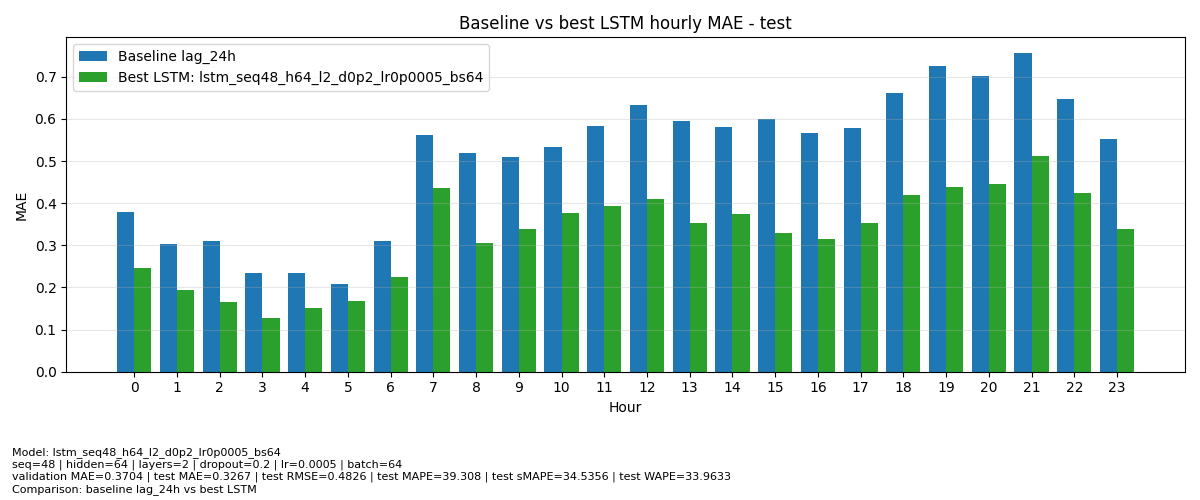

### Baseline vs LSTM - distribucija greske

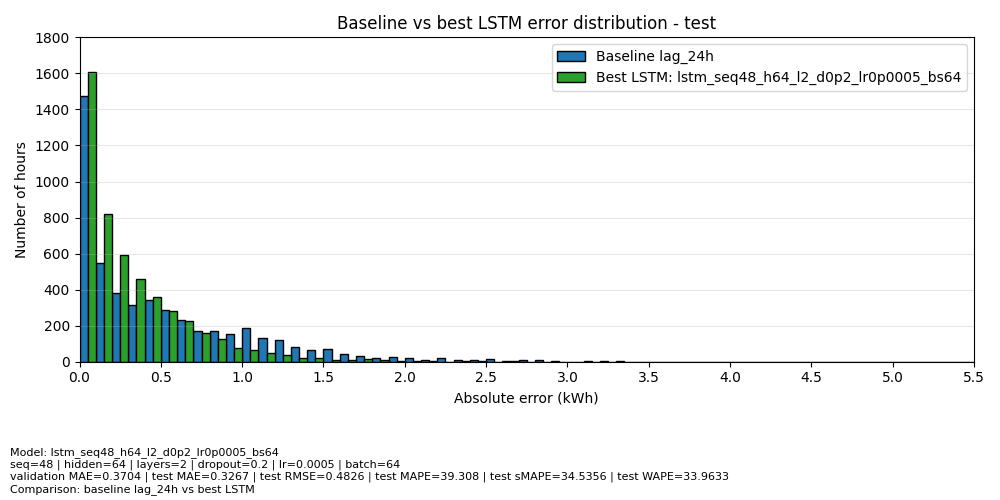

### Baseline vs LSTM - actual vs predicted

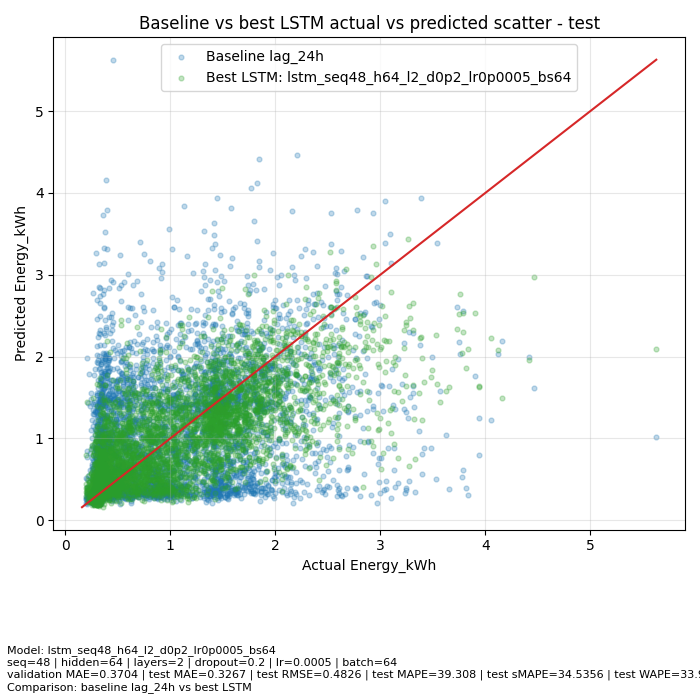

### Baseline vs Random Forest - MAE po satu

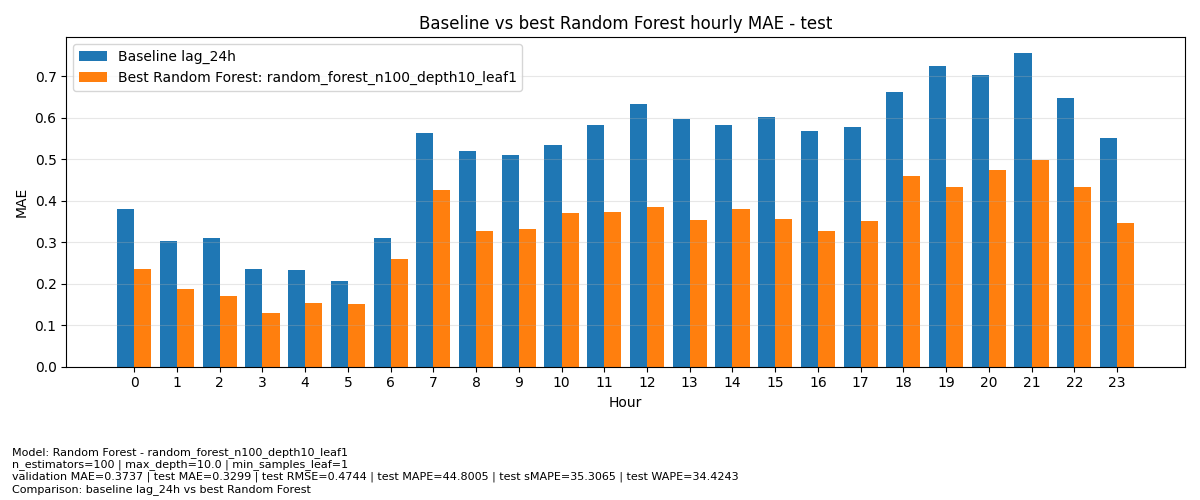

### Baseline vs Random Forest - distribucija greske

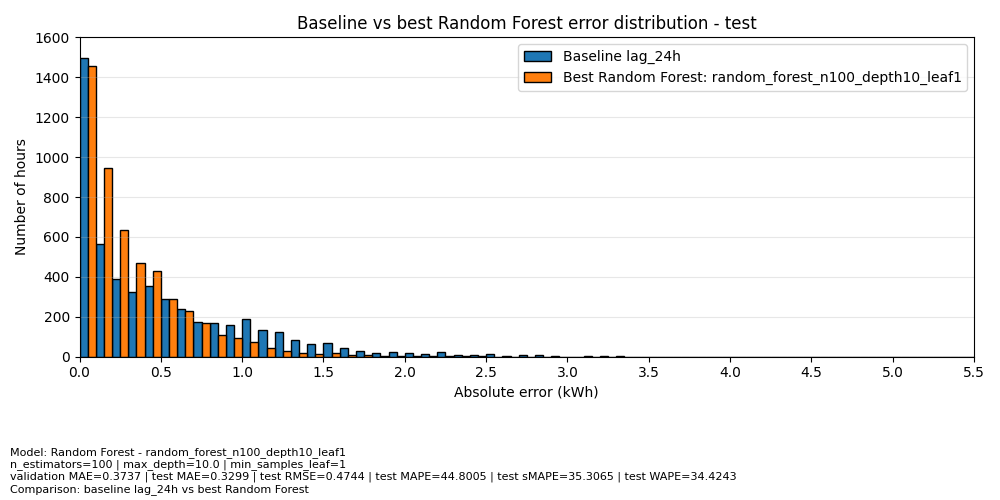

### Baseline vs Random Forest - actual vs predicted

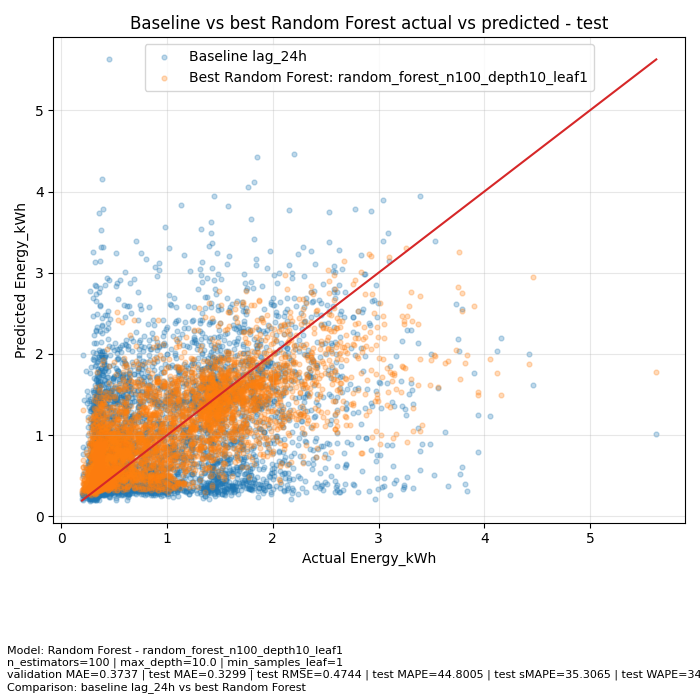

### Baseline vs Gradient Boosting - MAE po satu

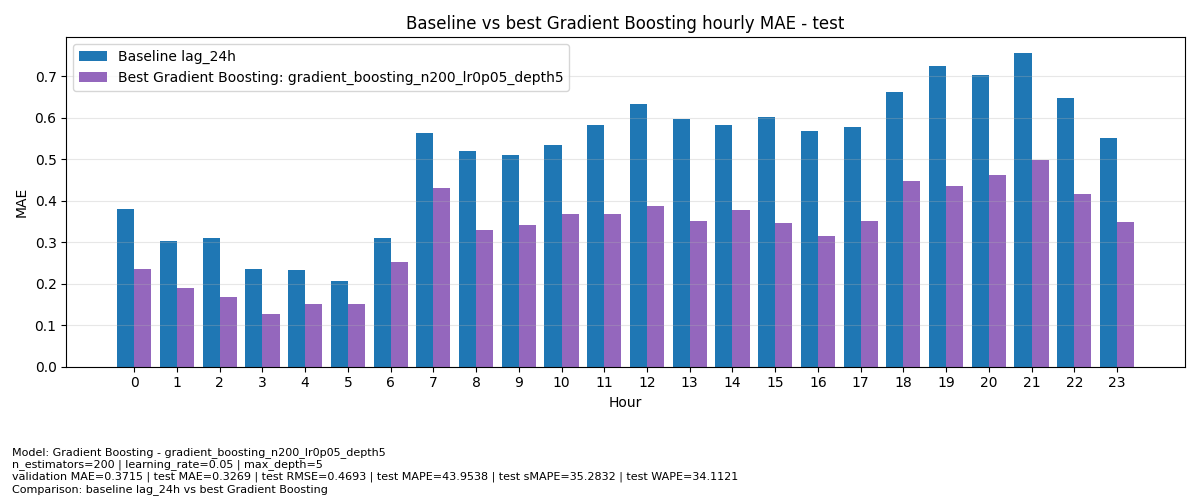

### Baseline vs Gradient Boosting - distribucija greske

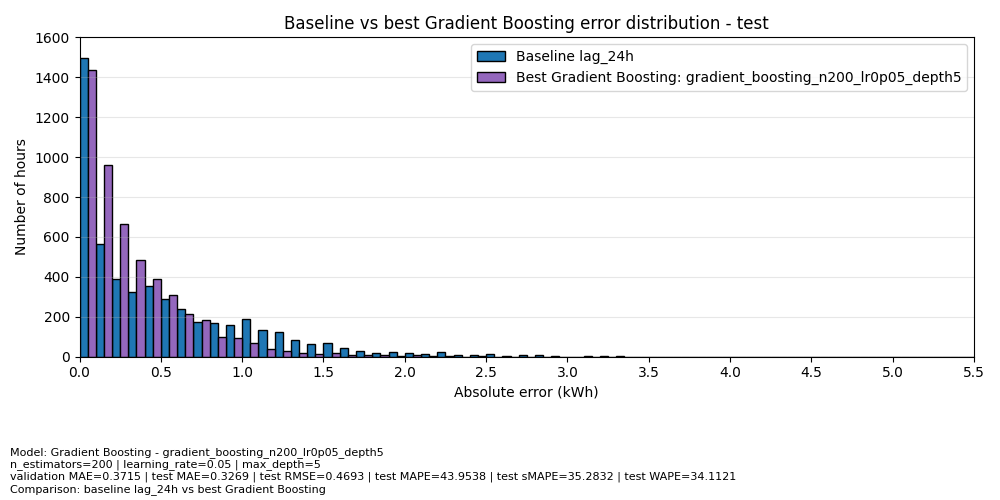

### Baseline vs Gradient Boosting - actual vs predicted

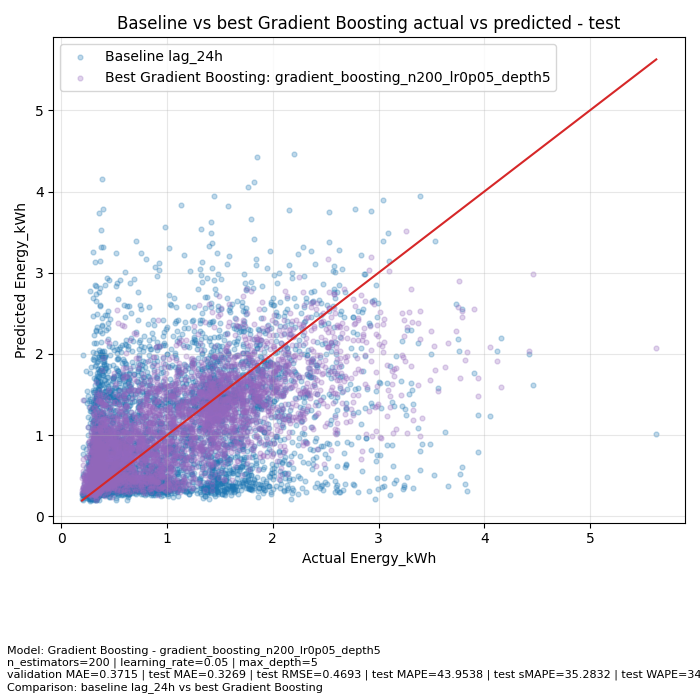

In [11]:
def model_name(family):
    row = read_first_row(BEST_MODEL_PATHS[family])
    return row["Model"] if row is not None else None


comparison_specs = [
    {
        "family": "GRU",
        "name": gru_name,
        "folder": "baseline_gru_compare_graphs",
        "slug": "baseline_gru_compare",
    },
    {
        "family": "LSTM",
        "name": lstm_name,
        "folder": "baseline_lstm_compare_graphs",
        "slug": "baseline_lstm_compare",
    },
    {
        "family": "Random Forest",
        "name": model_name("Random Forest"),
        "folder": "baseline_random_forest_compare_graphs",
        "slug": "baseline_random_forest_compare",
    },
    {
        "family": "Gradient Boosting",
        "name": model_name("Gradient Boosting"),
        "folder": "baseline_gradient_boosting_compare_graphs",
        "slug": "baseline_gradient_boosting_compare",
    },
]

comparison_graphs = []
for spec in comparison_specs:
    if spec["name"] is None:
        continue
    prefix = f"best_{spec['name']}_{spec['slug']}_test"
    graph_dir = GRAPHS_DIR / spec["folder"]
    comparison_graphs.extend([
        (graph_dir / f"{prefix}_hourly_mae.png", f"Baseline vs {spec['family']} - MAE po satu"),
        (graph_dir / f"{prefix}_error_distribution.png", f"Baseline vs {spec['family']} - distribucija greske"),
        (graph_dir / f"{prefix}_actual_vs_predicted_scatter.png", f"Baseline vs {spec['family']} - actual vs predicted"),
    ])

for path, title in comparison_graphs:
    show_image(path, title)


## 7. Međusobno poređenje najboljih modela

Prikaz najboljih modela: GRU, LSTM, Random Forest i Gradient Boosting. Cilj je da se vidi ne samo da li napredniji modeli pobeđuju baseline, već i koliko su međusobno blizu kada koriste isti skup pripremljenih osobina.

Ako su razlike male, to često znači da feature engineering nosi veliki deo kvaliteta rešenja. U tom slučaju izbor modela može zavisiti i od drugih faktora, kao što su brzina treniranja, jednostavnost objašnjavanja i stabilnost rezultata.


### Najbolji modeli - zbirne metrike

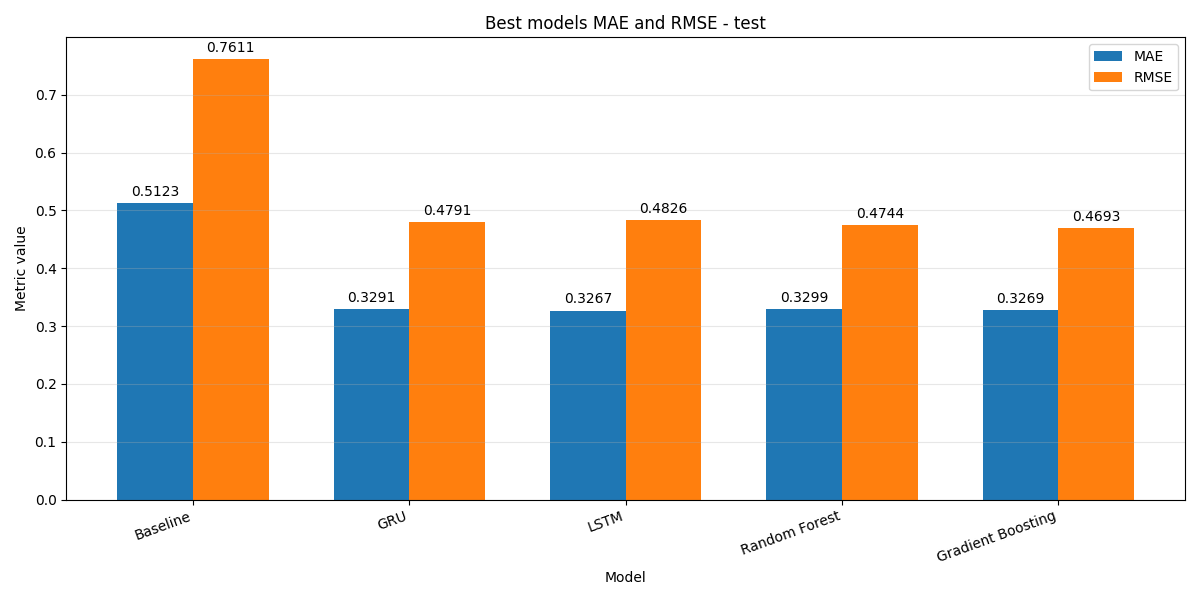

### Najbolji modeli - MAE po satu

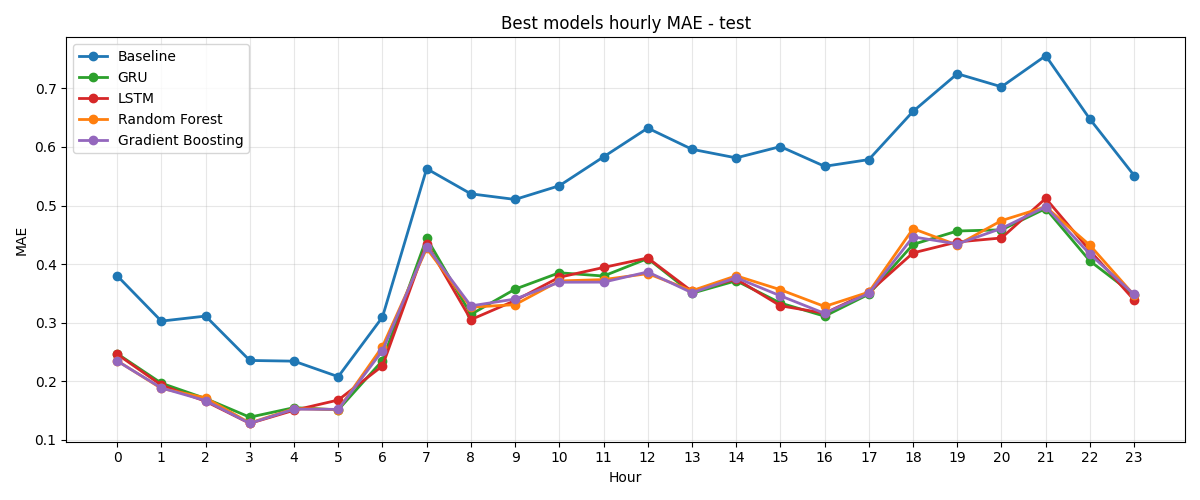

### Najbolji modeli - najbolji dan predikcija

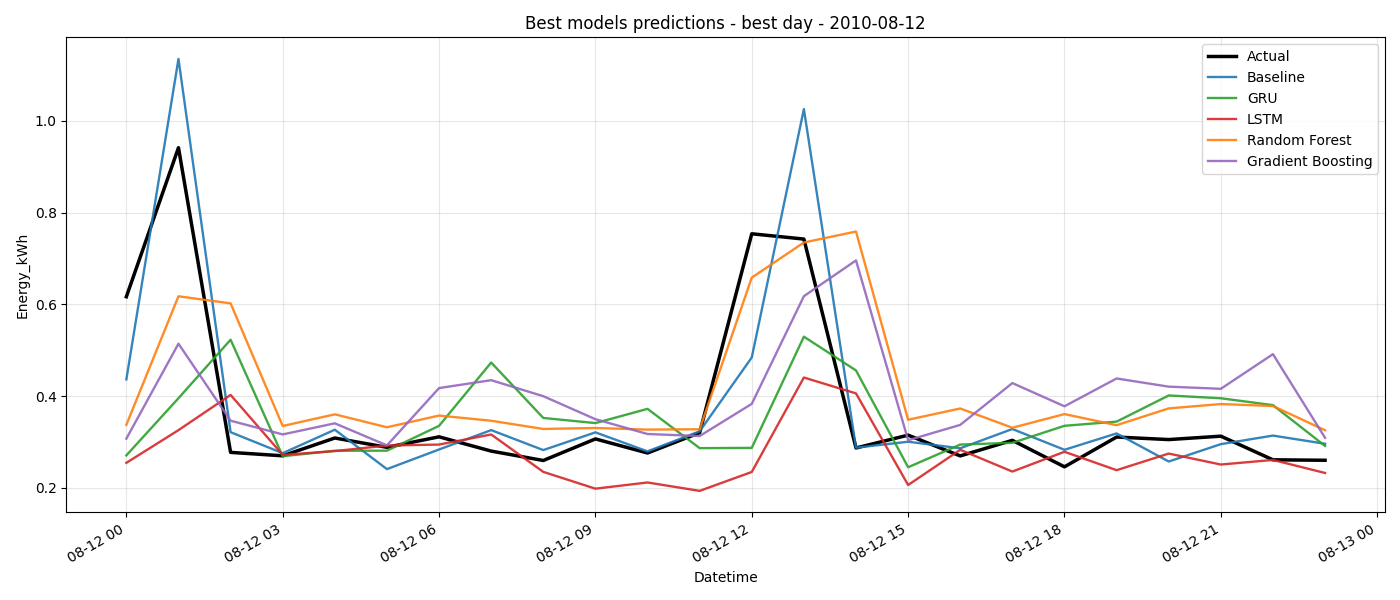

In [12]:
all_models_graphs_dir = GRAPHS_DIR / "all_models_compare_graphs"
for graph_name, title in [
    ("best_models_test_summary_metrics.png", "Najbolji modeli - zbirne metrike"),
    ("best_models_test_hourly_mae.png", "Najbolji modeli - MAE po satu"),
    ("best_models_best_day_predictions.png", "Najbolji modeli - najbolji dan predikcija"),
]:
    show_image(all_models_graphs_dir / graph_name, title)


## 8. Zaključak

Baseline je jak jer potrošnja često prati dnevni obrazac. Ipak, GRU, LSTM i tree modeli značajno smanjuju grešku, jer koriste širi kontekst: kalendarske osobine, prethodne vrednosti i rolling statistike.

Razlike između najboljih modela su relativno male, što pokazuje da je kvalitetan feature engineering uhvatio najvažnije obrasce u podacima. Za dalji rad imalo bi smisla proveriti dodatne spoljne faktore, na primer temperaturu, sezonu grejanja/hlađenja itd. jer bi oni mogli dodatno objasniti promene u potrošnji.
